In [63]:
import seaborn as sns
from pathlib import Path
import json, math, platform, warnings
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import pandas as pd
import scipy
import sklearn

from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, log_loss, matthews_corrcoef,
    precision_recall_curve, precision_score, recall_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.model_selection import (
    RandomizedSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
    cross_validate, learning_curve, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree 
from scipy import stats


In [7]:
df=sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [42]:
X=df.drop("species", axis=1)
y=df["species"]
print(X.shape, y.shape)
print(X.head())
print(y.head())
print(y.unique())

(150, 4) (150,)
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object
['setosa' 'versicolor' 'virginica']


In [75]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)
model = DecisionTreeClassifier(
    criterion="gini",      # or "entropy"
    max_depth=5,           # Maximum depth of the tree
    min_samples_split=2,   # Minimum samples required to split a node
    min_samples_leaf=1,    # Minimum samples required at a leaf node
    random_state=42
)
model.fit(Xtrain, ytrain)
print(Xtrain.shape, Xtest.shape, ytrain.shape, ytest.shape)
Xtrain['setosa'] = (ytrain == 'setosa').astype(int)
print(Xtrain.loc[:, 'setosa'].value_counts())
Xtrain['virginica'] = (ytrain == 'virginica').astype(int)
print(Xtrain.loc[:, 'virginica'].value_counts())
Xtrain['versicolor'] = (ytrain == 'versicolor').astype(int)
print(Xtrain.loc[:, 'versicolor'].value_counts())
print(Xtrain.describe())


(105, 4) (45, 4) (105,) (45,)
setosa
0    74
1    31
Name: count, dtype: int64
virginica
0    68
1    37
Name: count, dtype: int64
versicolor
0    68
1    37
Name: count, dtype: int64
       sepal_length  sepal_width  petal_length  petal_width      setosa  \
count    105.000000   105.000000    105.000000   105.000000  105.000000   
mean       5.842857     3.009524      3.870476     1.239048    0.295238   
std        0.833304     0.418910      1.721355     0.742720    0.458337   
min        4.300000     2.000000      1.100000     0.100000    0.000000   
25%        5.100000     2.800000      1.700000     0.400000    0.000000   
50%        5.800000     3.000000      4.300000     1.300000    0.000000   
75%        6.400000     3.300000      5.100000     1.800000    1.000000   
max        7.700000     4.200000      6.700000     2.500000    1.000000   

        virginica  versicolor  
count  105.000000  105.000000  
mean     0.352381    0.352381  
std      0.480003    0.480003  
min      0.0

In [76]:
print(Xtest.describe())


       sepal_length  sepal_width  petal_length  petal_width
count     45.000000    45.000000     45.000000    45.000000
mean       5.844444     3.168889      3.495556     1.106667
std        0.825050     0.458665      1.857045     0.806902
min        4.400000     2.200000      1.000000     0.100000
25%        5.200000     2.800000      1.500000     0.200000
50%        5.800000     3.100000      4.400000     1.300000
75%        6.400000     3.400000      5.000000     1.800000
max        7.900000     4.400000      6.900000     2.300000


In [77]:
print(ytrain.describe(include='all'))


count            105
unique             3
top       versicolor
freq              37
Name: species, dtype: object


In [79]:
print(ytest.describe())

count         45
unique         3
top       setosa
freq          19
Name: species, dtype: object


In [80]:
y_pred=model.predict(Xtest)
accuracy=accuracy_score(ytest, y_pred)
print("\nActual Species")
print(ytest.values)

print("\nPredicted Species")
print(y_pred)

# Display Accuracy
print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")
print(classification_report(ytest, y_pred))


Actual Species
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'setosa' 'setosa' 'virginica' 'versicolor'
 'setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'setosa']

Predicted Species
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'setosa' 'setosa' 'virginica' 'versicolor'
 'setosa' 'setosa' 'setosa' 'virginica' '

In [84]:
cm = confusion_matrix(ytest, y_pred)

# Display Confusion Matrix
cm_df = pd.DataFrame(
    cm,
    index=model.classes_,
    columns=model.classes_
)

print("Confusion Matrix")
print(cm_df)

Confusion Matrix
            setosa  versicolor  virginica
setosa          19           0          0
versicolor       0          13          0
virginica        0           0         13


<Axes: >

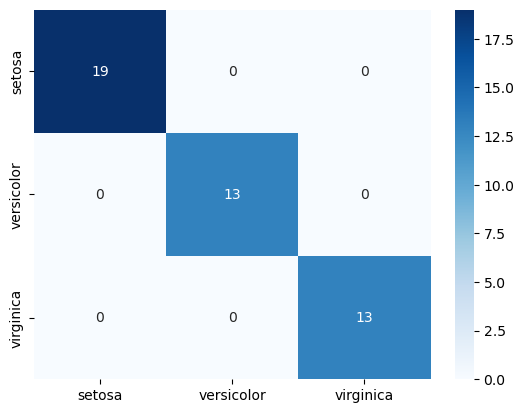

In [82]:
sns.heatmap(cm_df, annot=True, cmap="Blues", fmt="d")